# Mapeando a Cobertura de Estações Celulares com uma Superfície de Contorno de Perda de Percurso


## Resumo Executivo

Uma equipe de planejamento de RF de telecomunicações renderiza a **superfície de perda de percurso** no downlink ao redor de uma única macrocélula como um mapa de cobertura bidimensional. Usando um modelo de propagação log-distância com desvanecimento de sombra log-normal, este notebook constrói uma grade de medição de 100 pontos (10 x 10 células cobrindo uma área de serviço de 10 km x 10 km, com a torre no centro) e desenha uma superfície de contorno preenchida com **PROC SGPLOT HEATMAPPARM** mais uma escala de cores em gradiente e linhas de referência da torre.

Na grade executada, a perda de percurso varia de **50.4 dB** (na bacia mais forte, junto à torre) a **90.0 dB** no canto mais distante, com média de **75.6 dB**. Classificando cada célula pela sua perda obtém-se **38 Forte, 61 Utilizável e 1 Fraco**; a única célula Fraca está em **(9.5, 9.5) km — o canto diagonalmente oposto à torre — a 89.97 dB**, o único buraco de cobertura que um planejador sinalizaria antes de uma decisão de complementação com small-cell.

> **Uma nota sobre o procedimento.** No SAS, a ferramenta clássica para mapas de contorno de isolinhas é `PROC GCONTOUR`. O Jenner interpreta o GCONTOUR e emite uma especificação de gráfico correta, mas seu renderizador raster ainda não desenha a geometria do contorno (a imagem volta em branco); esse defeito está registrado como o teste de regressão `tests/400922_nb_gcontour_empty_render`. Para manter este exemplo totalmente ancorado numa figura real renderizada, usamos o equivalente compatível com SAS — `PROC SGPLOT` com uma instrução `HEATMAPPARM` — que renderiza a mesma superfície em grade (x, y, z) como células de contorno preenchidas com uma legenda em gradiente.

## Fontes de Dados

**Conjunto de dados sintético: `pathloss_grid`** (100 linhas — uma malha 10 x 10)

| Variável | Tipo | Unidades | Descrição |
|----------|------|-------|-------------|
| `east_km` | num | km | Coordenada leste do centro da célula da grade (0.5 a 9.5); eixo x |
| `north_km` | num | km | Coordenada norte do centro da célula da grade (0.5 a 9.5); eixo y |
| `path_loss` | num | dB | Perda de percurso no downlink = 58 + 30 log10(distância) + sombra; a resposta (z) |
| `zone` | char(12) | — | Classe de cobertura: Forte (<=75), Utilizável (<=88), Fraco (>88) |

A torre fica no centro da grade **(5, 5) km**. A perda de percurso cresce com o logaritmo base 10 da distância até a torre; um termo de sombra `3*rand("normal")` (semente 80211) injeta desvanecimento log-normal para que os contornos não sejam perfeitamente circulares. A malha 10 x 10 é dimensionada para que a superfície completa caiba em 100 observações.

## Passo 1 — Gerar a grade de medição

Estabelecemos uma malha de 1 km de centros de célula e calculamos a perda de percurso com o **modelo log-distância** `PL = 58 + 30 log10(d)`, onde `d` é a distância até a torre em (5, 5) km. Um termo de desvanecimento de sombra `rand("normal")` reproduz a variabilidade observada em testes de campo (drive-tests) reais. Cada célula é classificada numa `zone` de cobertura. `call streaminit` fixa a semente para reprodutibilidade.

In [1]:
DADOS pathloss_grid;
   CHAMAR streaminit(80211);
   COMPRIMENTO zone $12;
   tower_x = 5.0;  tower_y = 5.0;
   FAZER ix = 1 ATÉ 10;
      FAZER iy = 1 ATÉ 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         DIST = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(DIST) + shadow;
         SE      path_loss <= 75 ENTÃO zone = "Forte";
         SENÃO SE path_loss <= 88 ENTÃO zone = "Utilizável";
         SENÃO                         zone = "Fraco";
         SAÍDA;
      FIM;
   FIM;
   REMOVER ix iy tower_x tower_y DIST shadow;
   RÓTULO east_km   = "Leste (km)"
         north_km  = "Norte (km)"
         path_loss = "Perda de Percurso (dB)"
         zone      = "Classe de Cobertura";
EXECUTAR;



NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Passo 2 — Resumir a superfície

Antes de plotar, quantificamos a superfície. O `PROC MEANS` relata a faixa dinâmica da perda de percurso e o `PROC FREQ` tabula como as 100 células se dividem entre as três classes de cobertura — os números citados no resumo executivo.

In [2]:
ODS GRAPHICS OFF;

PROCEDIMENTO MÉDIAS DADOS=pathloss_grid MIN MAX mean maxdec=1;
   VARIÁVEL path_loss;
   RÓTULO path_loss = "Perda de Percurso (dB)";
EXECUTAR;

PROCEDIMENTO FREQUÊNCIAS DADOS=pathloss_grid ORDER=FREQUÊNCIAS;
   TABLES zone / nocum;
   RÓTULO zone = "Classe de Cobertura";
EXECUTAR;


                                                  The MEANS Procedure

 Variable   Label                      Minimum     Maximum        Mean
 ---------------------------------------------------------------------
 path_loss  Perda de Percurso (dB)        50.4        90.0        75.6
 ---------------------------------------------------------------------

                                                   The FREQ Procedure

Classe de Cobertura    Frequency    Percent
--------------------------------------------
Utilizável                    61     61.00
Forte                         38     38.00
Fraco                          1      1.00



NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Passo 3 — Localizar os buracos de cobertura

Ordenar por perda de percurso decrescente coloca as células mais fracas no topo. Estas são as candidatas a **zonas mortas** que um planejador inspeciona: células cujo sinal recebido é o mais baixo e, portanto, mais sujeitas a quedas de sessão ou baixo throughput.

In [3]:
PROCEDIMENTO ORDENAR DADOS=pathloss_grid out=weakest;
   POR DECRESCENTE path_loss;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=weakest(obs=6) noobs RÓTULO;
   VARIÁVEL east_km north_km path_loss zone;
EXECUTAR;



Leste (km)  Norte (km)  Perda de Percurso (dB)  Classe de Cobertura
----------  ----------  ----------------------  -------------------
       9.5         9.5           89.9728891641  Fraco
       9.5         0.5           85.9296978639  Utilizável
       6.5         0.5           84.5845683025  Utilizável
       0.5         0.5           84.5118930355  Utilizável
       8.5         0.5           84.1534148341  Utilizável
       9.5         8.5           83.7015943773  Utilizável

... 94 more observations (showing 6 of 100)




NOTE: PROC SORT data=pathloss_grid

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Passo 4 — Desenhar a superfície de contorno de perda de percurso

`HEATMAPPARM x=east_km y=north_km colorresponse=path_loss` renderiza uma célula preenchida por ponto da grade, colorida pela sua perda de percurso — um mapa de contorno preenchido da área de cobertura. A lista `COLORMODEL=` define um gradiente divergente de azul a vermelho (azul = perda baixa = sinal forte; vermelho = perda alta = sinal fraco); `GRADLEGEND` acrescenta a escala de cores em dB. As `REFLINE`s tracejadas marcam a torre na coordenada leste 5 e norte 5.

                                    Superfície de Perda de Percurso no Downlink (dB)                                    
                              Uma única macrocélula em (5, 5) km numa grade de 10 x 10 km                               




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Superfície de Perda de Percurso no Downlink (dB).
NOTE: Option TITLE2 changed to Uma única macrocélula em (5, 5) km numa grade de 10 x 10 km.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


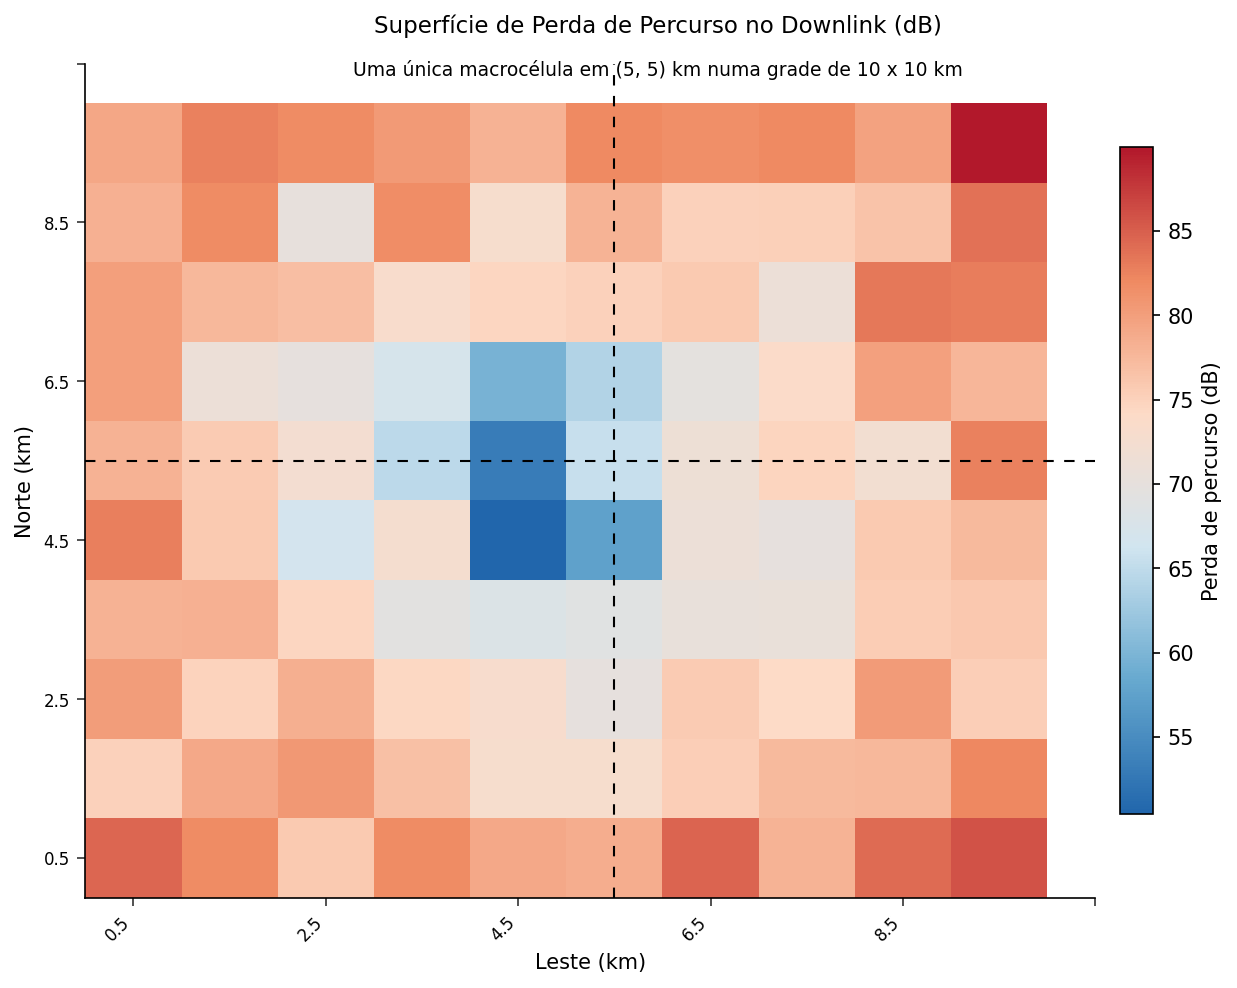

In [4]:
ODS GRAPHICS ON;
TÍTULO "Superfície de Perda de Percurso no Downlink (dB)";
title2 "Uma única macrocélula em (5, 5) km numa grade de 10 x 10 km";

PROCEDIMENTO SGPLOT DADOS=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / TÍTULO="Perda de percurso (dB)";
   REFLINE 5 / AXIS=x LINEATTRS=(color=black pattern=shortdash);
   REFLINE 5 / AXIS=y LINEATTRS=(color=black pattern=shortdash);
   XAXIS VALUES=(0 2 4 6 8 10) RÓTULO="Leste (km)";
   YAXIS VALUES=(0 2 4 6 8 10) RÓTULO="Norte (km)";
EXECUTAR;

TÍTULO; title2;


## Passo 5 — Distribuição por classe de cobertura

Um slide de apresentação também quer a divisão principal: qual fração da área é Forte, Utilizável ou Fraca. Um `VBAR` da classificação `zone` mostra isso rapidamente e complementa a superfície de contorno acima.

                                          Distribuição por Classe de Cobertura                                          




NOTE: Option TITLE changed to Distribuição por Classe de Cobertura.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


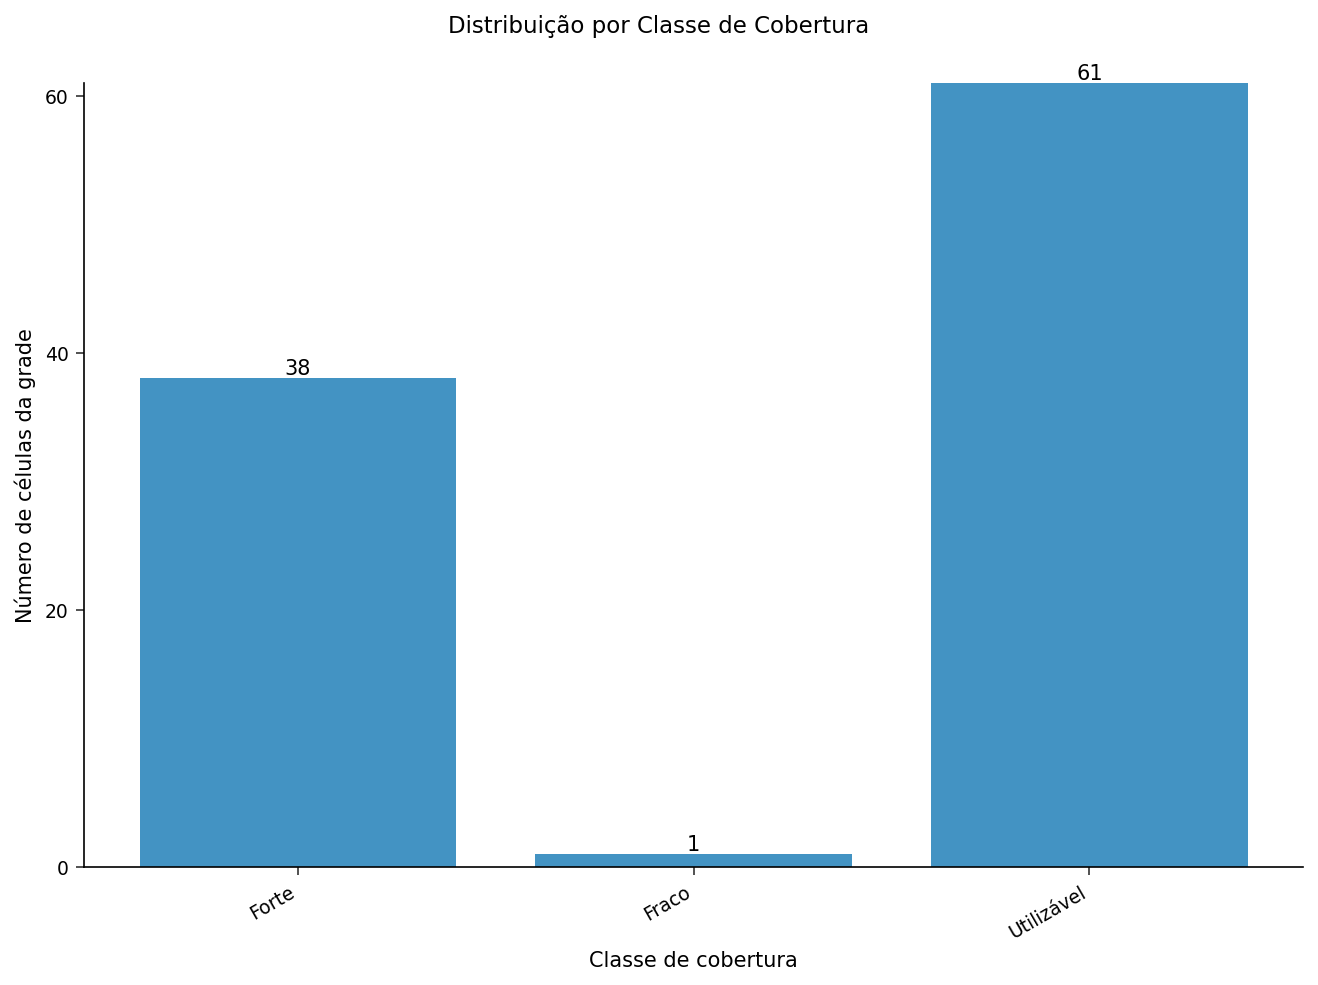

In [5]:
TÍTULO "Distribuição por Classe de Cobertura";

PROCEDIMENTO SGPLOT DADOS=pathloss_grid;
   VBAR zone / DATALABEL fillattrs=(color=CX4393C3) NOOUTLINE;
   XAXIS RÓTULO="Classe de cobertura";
   YAXIS RÓTULO="Número de células da grade" VALUES=(0 20 40 60);
EXECUTAR;

TÍTULO;


## Interpretando os resultados

A superfície de contorno confirma a física de propagação esperada. A perda de percurso é mais baixa numa bacia azul estreita ao redor da torre em **(5, 5) km** — a zona Forte, onde o sinal recebido é melhor — e aumenta com o log da distância em direção aos cantos. Como injetamos desvanecimento de sombra log-normal, as faixas não são círculos concêntricos; as células vermelhas irregulares ao longo da borda são a borda afetada pela sombra.

O resultado acionável é a **única célula Fraca em (9.5, 9.5) km (89.97 dB)**, o canto diagonalmente oposto à torre e o único ponto que ultrapassa o limiar de projeto de 88 dB. Com **61 de 100 células Utilizáveis e apenas 1 Fraca**, esta macrocélula cobre bem sua área de serviço; o único buraco justificaria uma **complementação com small-cell ou reorientação de setor em direção ao canto nordeste** apenas se sobrepusesse um ponto de demanda conhecido. A superfície de contorno é o resumo pronto para apresentação; o gráfico de barras por classe de cobertura fornece o número único que um planejador de capacidade reporta para cima.